In [17]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

price_data = pd.read_csv('../data/round1/prices_combined.csv', header=0, sep=';')




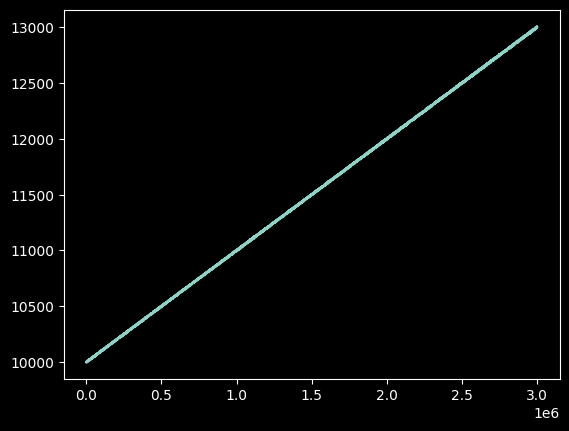

In [18]:
pepper_data = price_data[price_data['product'] == 'INTARIAN_PEPPER_ROOT']
pepper_prices = pepper_data['mid_price'].replace(0, np.nan).ffill()

diffed = pepper_prices.diff(1)
plt.plot(pepper_data['timestamp'], pepper_prices)

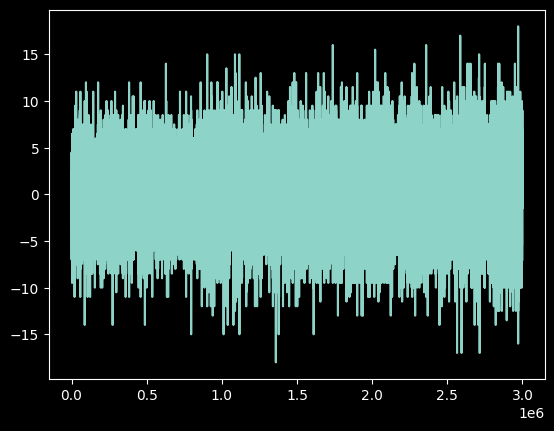

In [19]:
plt.plot(pepper_data['timestamp'], diffed)

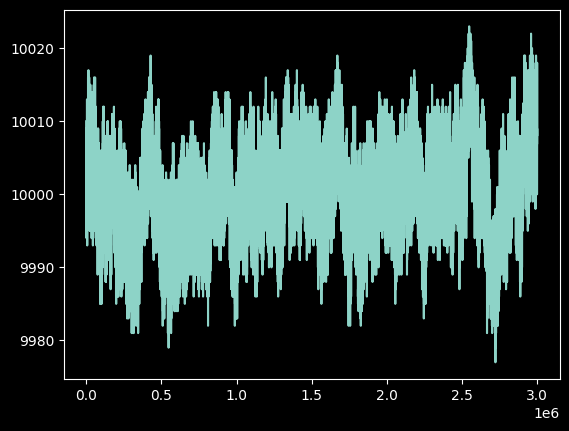

In [20]:
osmium_data = price_data[price_data['product'] == 'ASH_COATED_OSMIUM']
osmium_prices = osmium_data['mid_price'].replace(0, np.nan).ffill()

osmium_diffed = osmium_prices.diff(1)
plt.plot(osmium_data['timestamp'], osmium_prices)

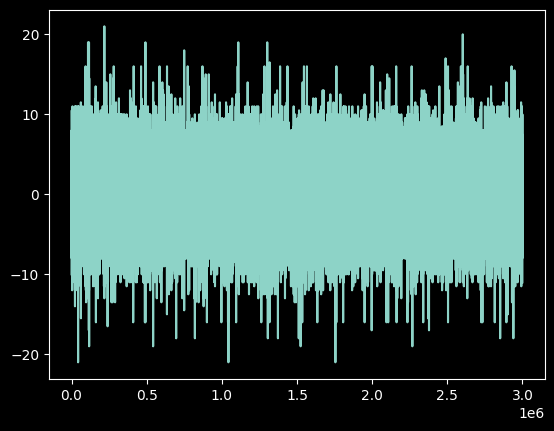

In [21]:
plt.plot(osmium_data['timestamp'], osmium_diffed)

In [23]:
print(osmium_prices.autocorr(lag=1))   # should be ~1.0 for random walk
print(osmium_prices.autocorr(lag=2))   # also ~0 for pure random walk
print(osmium_prices.autocorr(lag=3))
print(osmium_prices.autocorr(lag=4))

print(osmium_diffed.autocorr())
print(osmium_diffed.autocorr(lag=2))
print(osmium_diffed.autocorr(lag=3))
print(osmium_diffed.autocorr(lag=4))

0.7576437103540805
0.7548925060962116
0.7531318716691332
0.7518159674363395
-0.4942830010752726
-0.0021140786638602135
-0.0009178833910895684
0.0024296624231119257


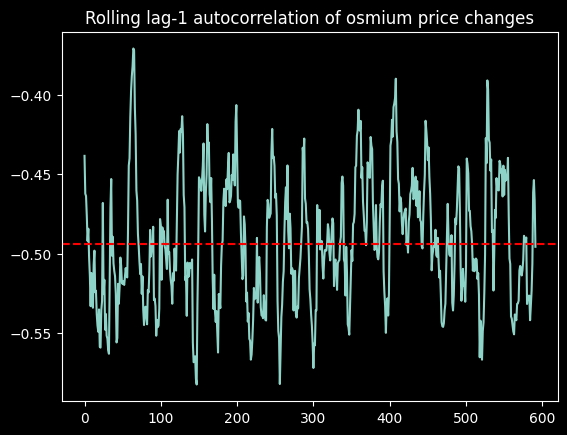

In [27]:
window = 400  # adjust based on how many timestamps you have
step = 50
rolling_autocorr = [
    osmium_diffed[i:i+window].autocorr(lag=1)
    for i in range(0, len(diffed)-window, step)  # 50% overlapping windows
]

plt.plot(rolling_autocorr)
plt.axhline(-0.494, color='red', linestyle='--', label='full sample mean')
plt.title('Rolling lag-1 autocorrelation of osmium price changes')
plt.show()